In [26]:
import pandas as pd

df = pd.read_excel("course_ML.xlsx")


In [27]:
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


In [28]:
df = df.drop(columns=["Unnamed: 0"])

In [29]:
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df.shape

(1001, 213)

In [31]:
df.dtypes.value_counts()

float64    107
int64      106
Name: count, dtype: int64

In [32]:
df.isnull().sum()

IC50, mM             0
CC50, mM             0
SI                   0
MaxAbsEStateIndex    0
MaxEStateIndex       0
                    ..
fr_thiazole          0
fr_thiocyan          0
fr_thiophene         0
fr_unbrch_alkane     0
fr_urea              0
Length: 213, dtype: int64

In [33]:
missing_count = df.isnull().sum()
missing_share = df.isnull().mean().sort_values(ascending=False)
missing_summary = pd.DataFrame({"missing_count": missing_count,"missing_share": missing_share}).sort_values("missing_share",ascending=False)

missing_summary.head(20)

,missing_count,missing_share
BCUT2D_CHGHI,3,0.002997
BCUT2D_LOGPHI,3,0.002997
BCUT2D_CHGLO,3,0.002997
BCUT2D_LOGPLOW,3,0.002997
BCUT2D_MRHI,3,0.002997
BCUT2D_MWHI,3,0.002997
BCUT2D_MRLOW,3,0.002997
BCUT2D_MWLOW,3,0.002997
MaxPartialCharge,3,0.002997
MinAbsPartialCharge,3,0.002997


Пропусков очень мало, заполним медианой, ничего не будем удалять

In [34]:
#нахожу столмбцы с пропусками
missing_count = df.isnull().sum()
missing_share = df.isnull().mean()

cols_with_nans = missing_count[missing_count > 0].index.tolist()
print(cols_with_nans)

['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']


In [35]:
#заполняем медианой
for col in cols_with_nans:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [36]:
df.isnull().sum().sum()

np.int64(0)

In [37]:
df.describe()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,348.262234,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,126.946370,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,264.321000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,315.457000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,409.283000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [38]:
targets = ["IC50, mM", "CC50, mM", "SI"]
desc_targets = df[targets].describe().T
print(desc_targets)

           count        mean         std       min        25%         50%  \
IC50, mM  1001.0  222.805156  402.169734  0.003517  12.515396   46.585183   
CC50, mM  1001.0  589.110728  642.867508  0.700808  99.999036  411.039342   
SI        1001.0   72.508823  684.482739  0.011489   1.433333    3.846154   

                 75%           max  
IC50, mM  224.975928   4128.529377  
CC50, mM  894.089176   4538.976189  
SI         16.566667  15620.600000  


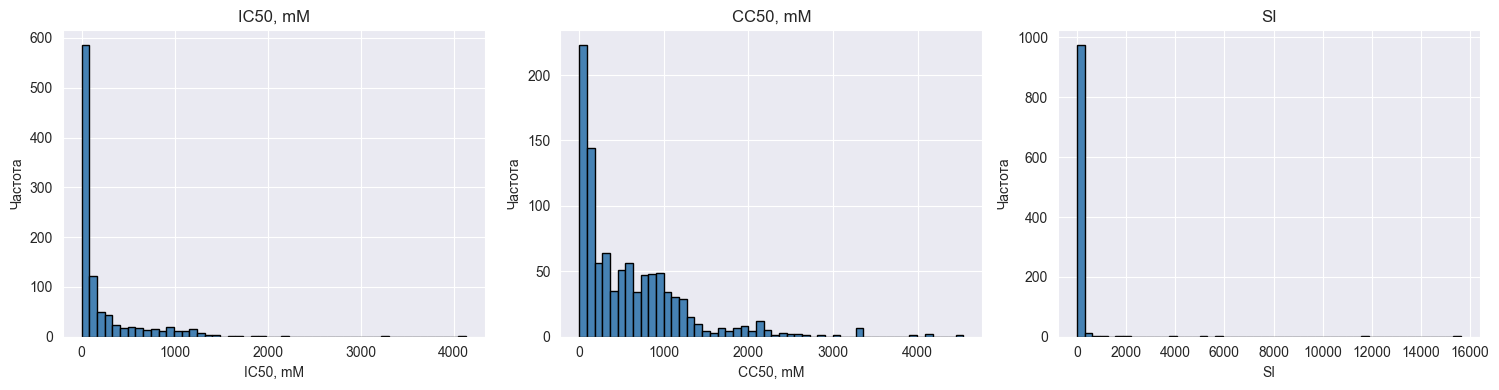

In [39]:
import matplotlib.pyplot as plt
import numpy as np

targets = ["IC50, mM", "CC50, mM", "SI"]

plt.figure(figsize=(15, 4))
for i, col in enumerate(targets, 1):
    plt.subplot(1, 3, i)
    plt.hist(df[col], bins=50, color="steelblue", edgecolor="black")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Частота")

plt.tight_layout()
plt.show()

IC50 - срднее в 5 раз больше медианы, максимум в 18 раз больше верхнего квартиля, сильный скос вправо.
CC50 - среднее выше медианы, так же сильный скок вправо.
SI - среднее больше медианы в 19 раз! Большая часть значений ниже 20, но некоторые достигают 15620. Так же сильный скос вправо.
Что бы сгладить распределения, предлагаю логарифмировать цп.

In [40]:
eps = 1e-6
df["log10_IC50"] = np.log10(df["IC50, mM"] + eps)
df["log10_CC50"] = np.log10(df["CC50, mM"] + eps)
df["log10_SI"]   = np.log10(df["SI"] + eps)

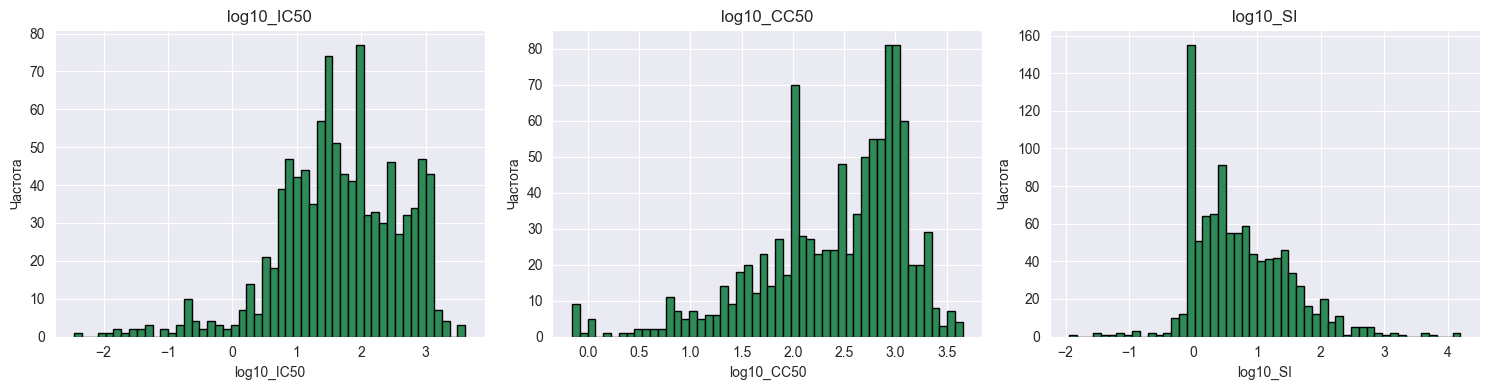

In [41]:
log_targets = ["log10_IC50", "log10_CC50", "log10_SI"]
plt.figure(figsize=(15, 4))
for i, col in enumerate(log_targets, 1):
    plt.subplot(1, 3, i)
    plt.hist(df[col], bins=50, color="seagreen", edgecolor="black")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Частота")
plt.tight_layout()
plt.show()

После логарифмирования картинка стала лучше

C:\Users\Denlex\AppData\Local\Temp\ipykernel_8008\3239970724.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["IC50, mM"], df["CC50, mM"], df["SI"]],labels=["IC50, mM", "CC50, mM", "SI"],showfliers=True)


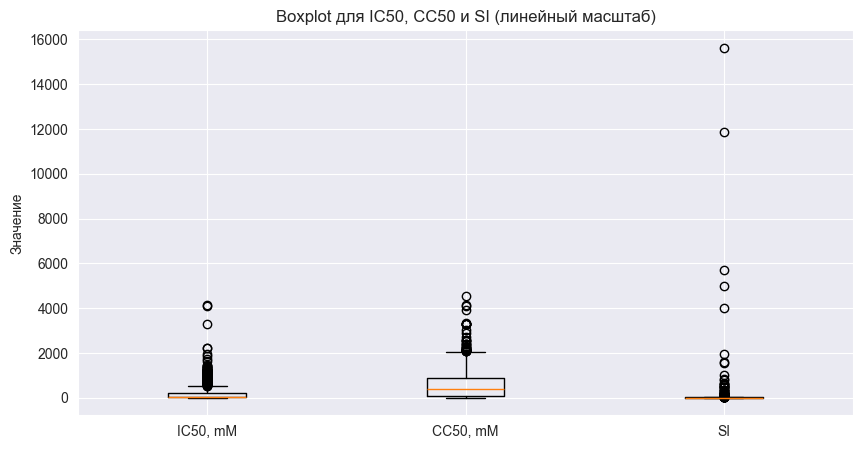

In [42]:
plt.figure(figsize=(10, 5))

plt.boxplot([df["IC50, mM"], df["CC50, mM"], df["SI"]],labels=["IC50, mM", "CC50, mM", "SI"],showfliers=True)
plt.ylabel("Значение")
plt.title("Boxplot для IC50, CC50 и SI (линейный масштаб)")
plt.yscale("linear")
plt.show()

Медианы всех трех показателей расположены ближе к нижним квартилям. У SI огромный диапазон значений => большое число потенциальных выбросов.

In [43]:
targets = ["IC50, mM", "CC50, mM", "SI"]

corr_targets = df[targets].corr(method="pearson")
print(corr_targets)

          IC50, mM  CC50, mM        SI
IC50, mM  1.000000  0.521346 -0.056604
CC50, mM  0.521346  1.000000 -0.006818
SI       -0.056604 -0.006818  1.000000


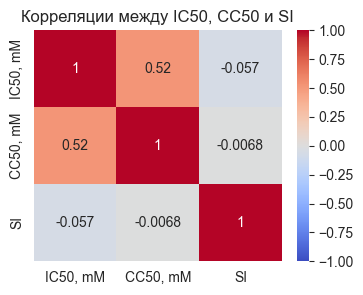

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
sns.heatmap(corr_targets, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляции между IC50, CC50 и SI")
plt.show()

Между IC50 и CC50 умеренная положительная корреляция, остальные корреляции стремятся к нулю. Для начала я хочу лично для себя проверить, действительно ли Si = CC50/IC50. Далее сделаю матрицу для лог-трансформированных таргетов.

In [45]:
#теоретический SI как отношение CC50/IC50
si_ratio = df["CC50, mM"] / df["IC50, mM"]

#сравним с колонкой SI
corr_si = np.corrcoef(si_ratio, df["SI"])[0, 1]

print("Корреляция (CC50/IC50)  SI:", corr_si)
print(df["SI"].describe())
print(si_ratio.describe())

Корреляция (CC50/IC50)  SI: 1.0
count     1001.000000
mean        72.508823
std        684.482739
min          0.011489
25%          1.433333
50%          3.846154
75%         16.566667
max      15620.600000
Name: SI, dtype: float64
count     1001.000000
mean        72.508823
std        684.482739
min          0.011489
25%          1.433333
50%          3.846154
75%         16.566667
max      15620.600000
dtype: float64


In [46]:
log_targets = ["log10_IC50", "log10_CC50", "log10_SI"]

corr_log = df[log_targets].corr(method="pearson")
print(corr_log)

            log10_IC50  log10_CC50  log10_SI
log10_IC50    1.000000    0.615896 -0.663433
log10_CC50    0.615896    1.000000  0.180875
log10_SI     -0.663433    0.180875  1.000000


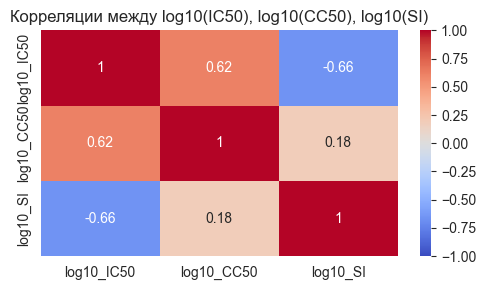

In [47]:
plt.figure(figsize=(5, 3))
sns.heatmap(corr_log, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляции между log10(IC50), log10(CC50), log10(SI)")
plt.tight_layout()
plt.show()

Тут картина сильно поменялась, в отличие от исходного маштаба, логарифмированные таргеты показали лучшую структуру связей.

In [48]:
#корреляция с дискрипторами
descriptor_cols = [c for c in df.columns if c not in targets]

#общая корреляционная матрица по числовым признакам
corr_full = df[descriptor_cols + targets].corr()

def top_correlated(target, k=10):
    corrs = corr_full[target].drop(labels=targets)
    log_targets = [f"log10_{t.split(',')[0].strip()}" for t in ["IC50", "CC50", "SI"]]
    log_targets = [c for c in log_targets if c in corrs.index]
    corrs = corrs.drop(labels=log_targets, errors="ignore")
    corrs_abs = corrs.abs().sort_values(ascending=False)
    top = corrs_abs.head(k).index
    return pd.DataFrame({"feature": top,"corr": corrs[top].values})

top_ic50 = top_correlated("IC50, mM", k=10)
top_cc50 = top_correlated("CC50, mM", k=10)
top_si   = top_correlated("SI", k=10)

print("10 признаков с IC50:")
print(top_ic50)

print("10 признаков с CC50:")
print(top_cc50)

print("10 признаков с SI:")
print(top_si)

10 признаков с IC50:
        feature      corr
0   VSA_EState4 -0.274203
1         Chi2n -0.257058
2     PEOE_VSA7 -0.255988
3         Chi2v -0.249164
4      fr_Ar_NH  0.245511
5  fr_Nhpyrrole  0.245511
6         Chi4v -0.243600
7         Chi4n -0.243497
8         Chi3n -0.239741
9         Chi3v -0.237759
10 признаков с CC50:
          feature      corr
0           MolMR -0.310111
1       LabuteASA -0.309191
2           MolWt -0.306439
3      ExactMolWt -0.306382
4  HeavyAtomCount -0.305169
5            Chi0 -0.304792
6            Chi1 -0.304380
7  HeavyAtomMolWt -0.303163
8          Kappa1 -0.302206
9           Chi1v -0.301525
10 признаков с SI:
            feature      corr
0          BalabanJ  0.162955
1            fr_NH2  0.160470
2         RingCount -0.124444
3         fr_Al_COO  0.102414
4           fr_COO2  0.101115
5            fr_COO  0.101115
6  NumAromaticRings -0.088064
7       VSA_EState4  0.087837
8  FpDensityMorgan1  0.087341
9       VSA_EState6 -0.082995


Если модель окажется адекватной, она должна будет подтвердить какие признаки являются важными в данной подборке

In [49]:
#таргеты и лог-таргеты
y_ic50 = df["IC50, mM"]
y_cc50 = df["CC50, mM"]
y_si   = df["SI"]

eps = 1e-6
df["log10_IC50"] = np.log10(df["IC50, mM"] + eps)
df["log10_CC50"] = np.log10(df["CC50, mM"] + eps)
df["log10_SI"]   = np.log10(df["SI"] + eps)

y_ic50_log = df["log10_IC50"]
y_cc50_log = df["log10_CC50"]
y_si_log   = df["log10_SI"]

In [50]:
df.to_csv("train_data_preprocessed.csv", index=False)

1001 обьект, 3 целевых показателя(IC50,CC50 и SI) и 213 числовых дескрипторов молекул. Пропуски были в BCUT2D и частичных зарядах(по 3 значения на столбец), заполнил пропуски медианами, что бы сохранить наблюдения. По анализу распределений: сильная правая ассиметрия и наличие выбросов, решено было использовать логарифмы цп. Проверил, что SI фактически является CC50/IC50. Так же анализ показал, что IC50 сильнее всего связан с топологическими и электронно-поверзностными дескрипторами, а CC50 связан с массой, размером и площадью поверхности молекулы.